In [1]:
import os
import time
import requests
import pandas as pd
import numpy as np
from pycoingecko import CoinGeckoAPI

# Create project folders
os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

print("✅ Ready!")

✅ Ready!


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
import sklearn, imblearn
print(sklearn.__version__)
print(imblearn.__version__)

1.8.0
0.14.1


In [3]:
def fetch_binance_ohlcv(symbol="BTCUSDT", interval="1d", limit=1000):
    url = "https://api.binance.com/api/v3/klines"
    params = {"symbol": symbol, "interval": interval, "limit": limit}
    
    response = requests.get(url, params=params, timeout=10)
    data = response.json()
    
    df = pd.DataFrame(data, columns=[
        "timestamp","open","high","low","close",
        "volume","close_time","quote_volume","trades",
        "taker_buy_base","taker_buy_quote","ignore"
    ])
    
    df = df[["timestamp","open","high","low","close","volume","trades"]]
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
    df[["open","high","low","close","volume"]] = \
        df[["open","high","low","close","volume"]].astype(float)
    df["trades"] = df["trades"].astype(int)
    df.set_index("timestamp", inplace=True)
    
    return df

print("✅ Function ready!")

✅ Function ready!


In [4]:
COINS = ["BTCUSDT","ETHUSDT","DOGEUSDT","XRPUSDT","SHIBUSDT"]

all_data = {}

for coin in COINS:
    print(f"⏳ Fetching {coin}...")
    df = fetch_binance_ohlcv(symbol=coin)
    all_data[coin] = df
    df.to_csv(f"data/raw/{coin}.csv")
    print(f"   ✅ {len(df)} rows saved")
    time.sleep(0.5)

print(f"\n🎉 Done! {len(all_data)} coins fetched")

⏳ Fetching BTCUSDT...


   ✅ 1000 rows saved


⏳ Fetching ETHUSDT...


   ✅ 1000 rows saved


⏳ Fetching DOGEUSDT...


...

⏳ Fetching XRPUSDT...


   ✅ 1000 rows saved


⏳ Fetching SHIBUSDT...


   ✅ 1000 rows saved



🎉 Done! 5 coins fetched


In [5]:
df_btc = all_data["BTCUSDT"]
print(df_btc.tail())
print("\nShape:", df_btc.shape)
print("\nColumns:", df_btc.columns.tolist())

                open      high       low     close       volume   trades
timestamp                                                               
2026-04-13  70741.56  74900.00  70566.99  74417.99  24230.21625  3673539
2026-04-14  74418.00  76038.00  73795.47  74131.55  26532.94456  4033448
2026-04-15  74131.55  75425.00  73514.00  74809.99  14425.04167  3187792
2026-04-16  74809.99  75534.76  73309.85  75154.29  17088.68777  3581890
2026-04-17  75154.28  75154.77  74529.40  74789.21   2015.92028   259330

Shape: (1000, 6)

Columns: ['open', 'high', 'low', 'close', 'volume', 'trades']


In [6]:
def label_pump_dump(df, price_threshold=0.05, volume_threshold=1.5, window=7):
    df = df.copy()
    df["price_change_pct"] = df["close"].pct_change(periods=window)
    df["volume_ma"]        = df["volume"].rolling(window=window).mean()
    df["volume_ratio"]     = df["volume"] / df["volume_ma"]
    
    df["is_pump_dump"] = (
        (df["price_change_pct"] > price_threshold) &
        (df["volume_ratio"]     > volume_threshold)
    ).astype(int)
    
    return df

# Apply to all coins
labeled_data = {}

for coin, df in all_data.items():
    labeled_df = label_pump_dump(df)
    labeled_data[coin] = labeled_df
    labeled_df.to_csv(f"data/raw/{coin}_labeled.csv")
    pumps = labeled_df["is_pump_dump"].sum()
    print(f"✅ {coin}: {pumps} P&D events labeled out of {len(labeled_df)} rows")

✅ BTCUSDT: 37 P&D events labeled out of 1000 rows
✅ ETHUSDT: 38 P&D events labeled out of 1000 rows
✅ DOGEUSDT: 83 P&D events labeled out of 1000 rows
✅ XRPUSDT: 45 P&D events labeled out of 1000 rows
✅ SHIBUSDT: 60 P&D events labeled out of 1000 rows


In [7]:
from sklearn.model_selection import train_test_split

combined = pd.concat(labeled_data.values()).dropna()
features = ["price_change_pct", "volume_ratio", "open", "high", "low", "close", "volume", "trades"]
X = combined[features]
y = combined["is_pump_dump"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
from imblearn.over_sampling import SMOTE

all_df = pd.concat(labeled_data.values()).dropna()
X_train = all_df.drop(columns=["is_pump_dump"])
y_train = all_df["is_pump_dump"]

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE : {pd.Series(y_resampled).value_counts().to_dict()}")

Before SMOTE: {0: 4702, 1: 263}
After SMOTE : {0: 4702, 1: 4702}


Class distribution:
  Normal (0)     : 4737
  Pump & Dump (1): 263
  Imbalance ratio: 18.0x


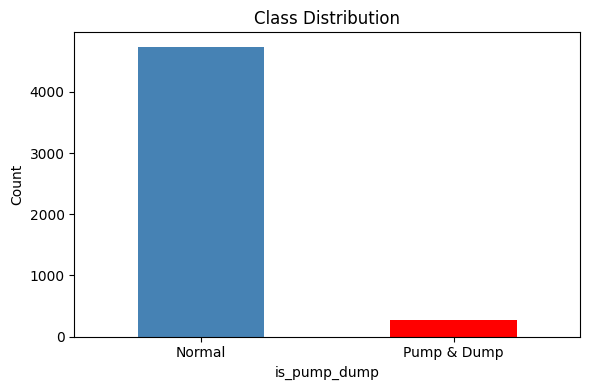

In [9]:
import matplotlib.pyplot as plt

all_labels = pd.concat([df["is_pump_dump"] for df in labeled_data.values()])

counts = all_labels.value_counts()
print("Class distribution:")
print(f"  Normal (0)     : {counts[0]}")
print(f"  Pump & Dump (1): {counts[1]}")
print(f"  Imbalance ratio: {counts[0]/counts[1]:.1f}x")

counts.plot(kind="bar", color=["steelblue","red"], figsize=(6,4))
plt.title("Class Distribution")
plt.xticks([0,1], ["Normal","Pump & Dump"], rotation=0)
plt.ylabel("Count")
plt.tight_layout()
plt.show()